## ⚙️ **Libraries Import**

In [45]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
!pip install torchview
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


"pkill" non � riconosciuto come comando interno o esterno,
 un programma eseguibile o un file batch.


PyTorch version: 2.5.1+cu121
Device: cuda


Sottodirectory o file -p gi� esistente.
Errore occorso durante l'elaborazione: -p.
Sottodirectory o file models gi� esistente.
Errore occorso durante l'elaborazione: models.


## ⏳ **Data Loading**

In [46]:
def load_images_from_folder(folder, img_size=(224, 224), pad_value=0, type='img_'):
    """
    Load images starting with 'img_', pad them to square, and resize.
    """
    images = []

    for filename in os.listdir(folder):
        # 1. FILTRO: Processa solo i file che iniziano con 'img_'
        if not filename.startswith(type):
            continue

        img = cv2.imread(os.path.join(folder, filename))

        # Controllo sicurezza
        if img is None:
            continue

        # Normalizzazione [0, 1] e conversione float
        img = (img / 255).astype(np.float32)

        # BGR to RGB
        img = img[..., ::-1]

        # 2. PADDING: Rendi l'immagine quadrata aggiungendo bordi
        h, w = img.shape[:2]
        max_dim = max(h, w)

        # Calcola quanto bordo aggiungere sopra/sotto o destra/sinistra
        delta_w = max_dim - w
        delta_h = max_dim - h
        top, bottom = delta_h // 2, delta_h - (delta_h // 2)
        left, right = delta_w // 2, delta_w - (delta_w // 2)

        # Aggiungi il bordo (padding)
        # value=[0, 0, 0] significa bordo nero. Se vuoi bianco usa [1, 1, 1]
        img = cv2.copyMakeBorder(
            img, 
            top, bottom, left, right, 
            cv2.BORDER_CONSTANT, 
            value=[pad_value, pad_value, pad_value]
        )

        # Ridimensiona a 224x224 (ora l'immagine è già quadrata, niente distorsione)
        img = cv2.resize(img, img_size)

        images.append(img)

    return np.array(images)

In [47]:
# Load images from the 'animals/' folder
train_path = 'C:/Users/pfili/OneDrive/Documenti/uni/2025-2026/ANN/project/challenge 2/an2dl2526c2/train_data'
train_images = load_images_from_folder(train_path)
train_masks = load_images_from_folder(train_path, type='mask_')


print(f"Loaded {len(train_images)}  images")
print(f"Loaded {len(train_masks)}  masks")


Loaded 1412  images
Loaded 1412  masks


In [77]:
train_labels = pd.read_csv("C:/Users/pfili/OneDrive/Documenti/uni/2025-2026/ANN/project/challenge 2/an2dl2526c2/train_labels.csv", header=0)
train_labels.head()


,sample_index,label
0,img_0000.png,Triple negative
1,img_0001.png,Luminal A
2,img_0002.png,Luminal A
3,img_0003.png,Luminal B
4,img_0004.png,HER2(+)


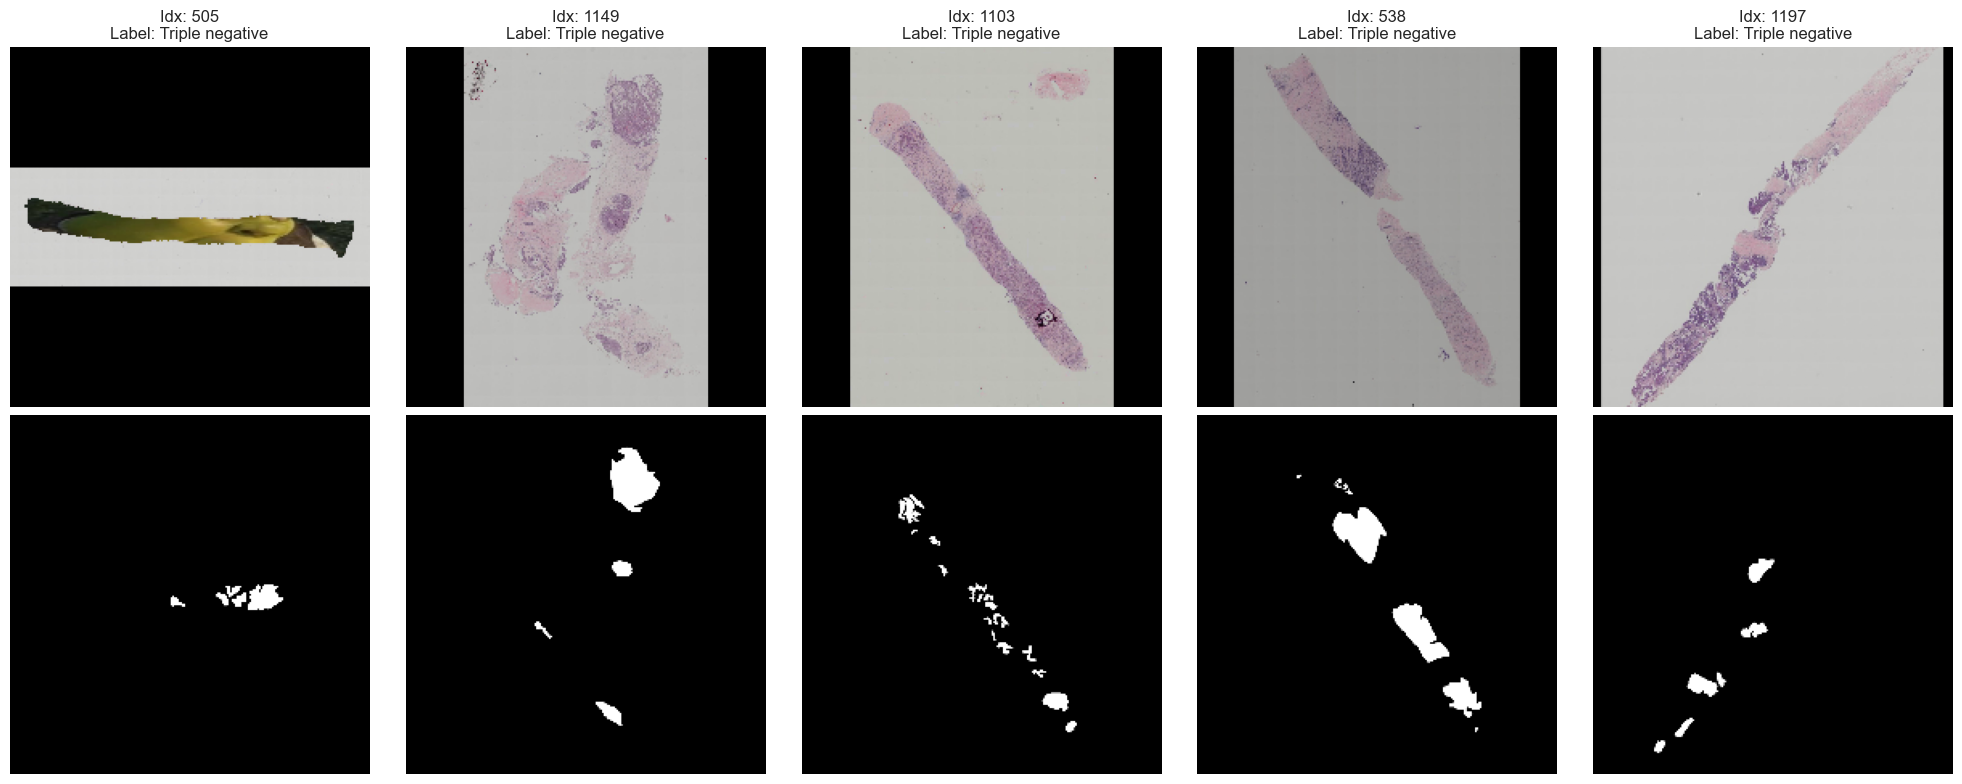

In [78]:

# Numero di immagini da mostrare
num_img = 5

# Generiamo 'num_img' indici casuali compresi tra 0 e la lunghezza del dataset
# random.sample assicura che non ci siano duplicati
indices = random.sample(range(len(train_images)), num_img)

# Creiamo la griglia: 2 righe (Img, Mask) e 'num_img' colonne
fig, axes = plt.subplots(2, num_img, figsize=(20, 8))

# Usiamo enumerate: 'i' è la posizione nel grafico (0,1,2...), 'idx' è l'indice reale dell'immagine (es. 45, 120...)
for i, idx in enumerate(indices):
    
    # --- RIGA 1: Immagine Originale ---
    ax_img = axes[0, i]
    ax_img.imshow(np.clip(train_images[idx], 0, 1))
    ax_img.set_title(f"Idx: {idx}\nLabel: {label_val}", fontsize=12) # Utile per sapere quale immagine è stata pescata
    ax_img.axis('off')

    # --- RIGA 2: Maschera Corrispettiva ---
    ax_mask = axes[1, i]
    # Uso cmap='gray' per vedere meglio la maschera
    ax_mask.imshow(np.clip(train_masks[idx], 0, 1), cmap='gray') 
    ax_mask.axis('off')

plt.tight_layout()
plt.show()

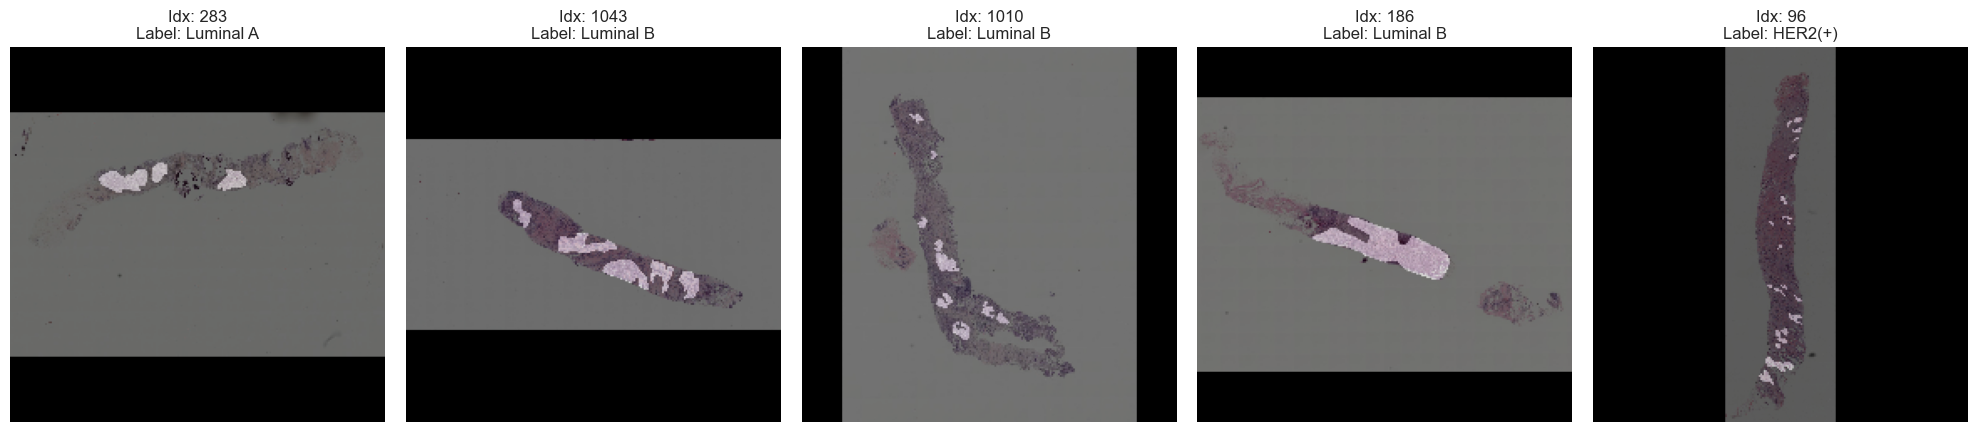

In [80]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Numero di immagini da mostrare
num_img = 5

# Generiamo 'num_img' indici casuali compresi tra 0 e la lunghezza del dataset
indices = random.sample(range(len(train_images)), num_img)

# Creiamo la griglia: 1 riga e 'num_img' colonne
# Ho ridotto leggermente l'altezza (da 8 a 6) visto che è una sola riga
fig, axes = plt.subplots(1, num_img, figsize=(20, 6))

# Gestione caso speciale: se num_img=1, axes non è una lista
if num_img == 1:
    axes = [axes]

for i, idx in enumerate(indices):
    ax = axes[i]
    
    # 1. Mostra l'immagine di fondo
    ax.imshow(np.clip(train_images[idx], 0, 1))
    
    # 2. Mostra la maschera sopra con trasparenza
    ax.imshow(np.clip(train_masks[idx], 0, 1), alpha=0.4, cmap='jet')
    
    # --- MODIFICA QUI: Aggiunta del titolo con la Label ---
    # Recuperiamo la label usando l'indice 'idx'
    label_val = train_labels['label'][idx]
    
    # Impostiamo il titolo (Mostra Indice e Label)
    ax.set_title(f"Idx: {idx}\nLabel: {label_val}", fontsize=12)
    
    ax.axis('off')

plt.tight_layout()
plt.show()